# Diagnosing a Cassandra Read-Latency Regression from Metrics & Logs

A distributed key-value store's read **p99 latency tripled** with no code change and no
deploy. This notebook walks the diagnosis end to end — from the client-side latency
symptom, to the server-side metrics that localize the cause, to the log line that names
it — and then shows the fix taking effect.

Everything here is generated by a **self-contained, reproducible rig**: a single-node
Apache Cassandra cluster in Docker, driven by a Python workload that deliberately
injects the fault and then remediates it (`run_experiment.py`). No proprietary data —
every number below comes from CSVs captured during one run, committed alongside this
notebook so the analysis is fully reproducible.

## The symptom

Operators page on read latency. The workload is a steady stream of partition reads
(`SELECT ... WHERE device_id = ? LIMIT 100`). For the first 60 seconds latency is flat
and healthy — then, with no change to the query or the client, p99 climbs sharply and
throughput falls off a cliff.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})

lat = pd.read_csv("data/latency_timeseries.csv")
metrics = pd.read_csv("data/metrics.csv")
phases = pd.read_csv("data/phases.csv")
WINDOW_S = 2  # latency aggregation window used by run_experiment.py

PHASE_COLOR = {"baseline": "#2e7d32", "fault": "#c62828", "recovery": "#1565c0"}

def shade_phases(ax):
    "Shade baseline / fault / recovery spans behind a time-series chart."
    for _, p in phases.iterrows():
        ax.axvspan(p.t_start, p.t_end, color=PHASE_COLOR[p.phase], alpha=0.06)
        ax.text((p.t_start + p.t_end) / 2, 0.97, p.phase.upper(),
                transform=ax.get_xaxis_transform(), ha="center", va="top",
                fontsize=9, color=PHASE_COLOR[p.phase], fontweight="bold")

### Headline: read latency over time

The fault is injected at **t = 60s**. p99 doesn't step up instantly — it *ramps*, which
is itself a clue: whatever is wrong is *accumulating*, not a single bad config flip.

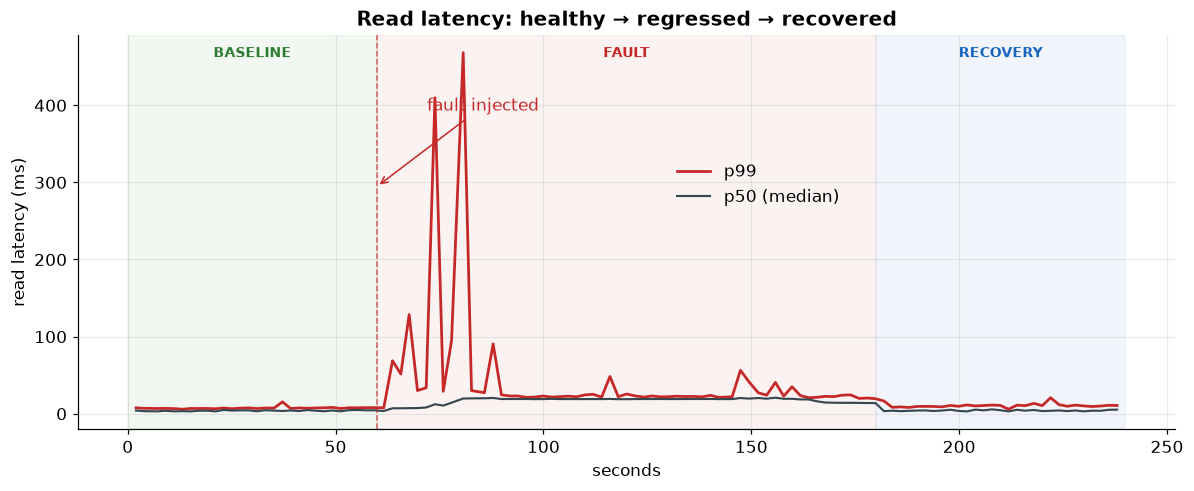

In [2]:
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.plot(lat.t_s, lat.p99_ms, color="#c62828", lw=1.8, label="p99")
ax.plot(lat.t_s, lat.p50_ms, color="#37474f", lw=1.4, label="p50 (median)")
shade_phases(ax)
ax.axvline(60, color="#c62828", ls="--", lw=1, alpha=0.7)
ax.annotate("fault injected", xy=(60, ax.get_ylim()[1]*0.6),
            xytext=(72, ax.get_ylim()[1]*0.8),
            arrowprops=dict(arrowstyle="->", color="#c62828"), color="#c62828")
ax.set_xlabel("seconds"); ax.set_ylabel("read latency (ms)")
ax.set_title("Read latency: healthy → regressed → recovered", fontweight="bold")
ax.legend(loc="center", bbox_to_anchor=(0.62, 0.62), frameon=False)
fig.tight_layout()
fig.savefig("latency_chart.png", dpi=150, bbox_inches="tight")  # standalone copy; portfolio hero is the Grafana render
plt.show()

In [3]:
def phase_mean(df, col):
    return df.groupby("phase")[col].mean().round(2)

summary = pd.DataFrame({
    "p50_ms": phase_mean(lat, "p50_ms"),
    "p99_ms": phase_mean(lat, "p99_ms"),
    "throughput_ops_s": (phase_mean(lat, "ops") / WINDOW_S).round(0),
}).reindex(["baseline", "fault", "recovery"])
print(summary)
print(f"\np99 fault / baseline   = {summary.p99_ms.fault / summary.p99_ms.baseline:0.1f}x")
print(f"throughput fault / base = {summary.throughput_ops_s.fault / summary.throughput_ops_s.baseline:0.2f}x")

          p50_ms  p99_ms  throughput_ops_s
phase                                     
baseline    3.86    7.42             214.0
fault      16.90   44.73              48.0
recovery    4.09   10.63             177.0

p99 fault / baseline   = 6.0x
throughput fault / base = 0.22x


Reads didn't just get slower — there were far **fewer** of them. A latency regression
that also tanks throughput points at the server spending real work *per read*, not at a
network blip or a slow client. Next question: work doing **what**?

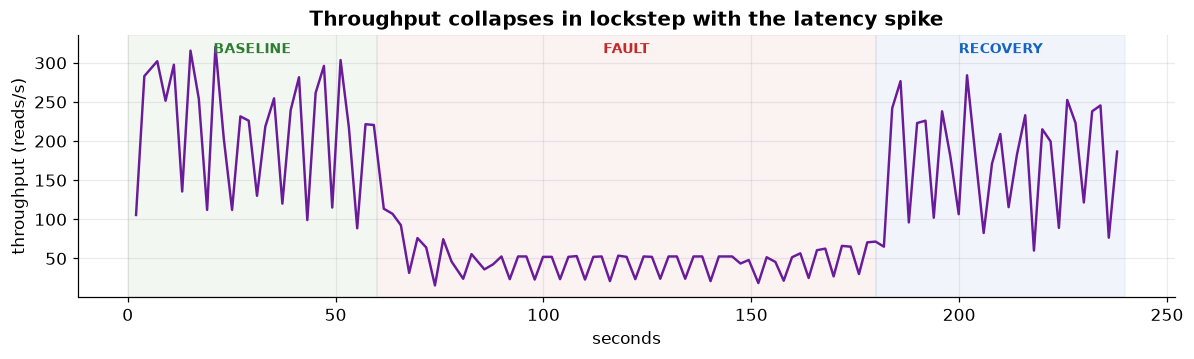

In [4]:
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(lat.t_s, lat.ops / WINDOW_S, color="#6a1b9a", lw=1.6)
shade_phases(ax)
ax.set_xlabel("seconds"); ax.set_ylabel("throughput (reads/s)")
ax.set_title("Throughput collapses in lockstep with the latency spike", fontweight="bold")
fig.tight_layout(); plt.show()

## Localizing the cause: server-side metrics

`nodetool tablestats` exposes a read-path metric that is the giveaway here —
**tombstones scanned per read**. A tombstone is a deletion marker; reads must scan over
them to find live data. Watch it ramp in perfect correlation with the latency curve,
while the SSTable count creeps up too.

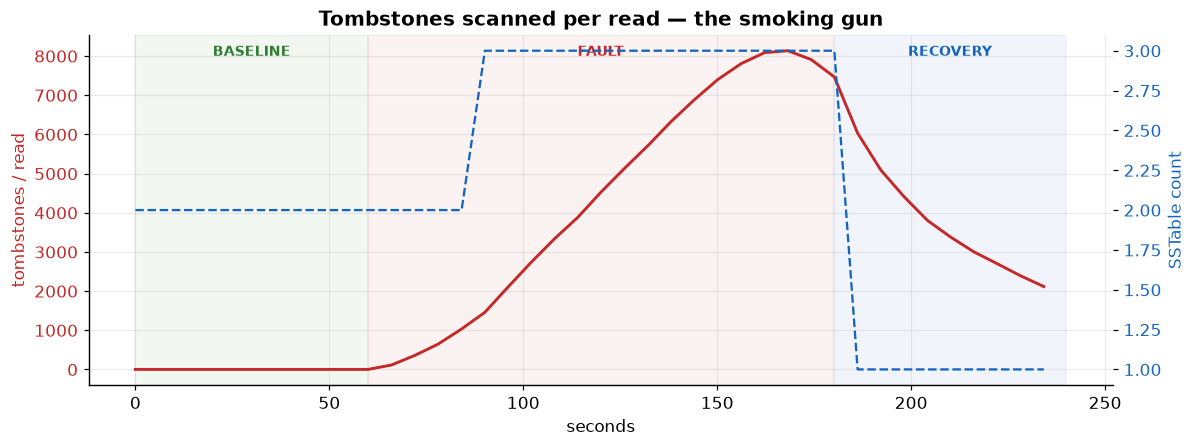

peak tombstones scanned per read: 20501


In [5]:
m = metrics.copy()
m["tomb_avg"] = pd.to_numeric(m["tombstones_per_read_avg"], errors="coerce")

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(m.t_s, m.tomb_avg, color="#c62828", lw=1.9, label="tombstones scanned / read (avg)")
shade_phases(ax)
ax.set_xlabel("seconds"); ax.set_ylabel("tombstones / read", color="#c62828")
ax.tick_params(axis="y", labelcolor="#c62828")

ax2 = ax.twinx(); ax2.grid(False); ax2.spines["top"].set_visible(False)
ax2.plot(m.t_s, m.sstable_count, color="#1565c0", lw=1.5, ls="--", label="SSTable count")
ax2.set_ylabel("SSTable count", color="#1565c0")
ax2.tick_params(axis="y", labelcolor="#1565c0")
ax.set_title("Tombstones scanned per read — the smoking gun", fontweight="bold")
fig.tight_layout(); plt.show()

print("peak tombstones scanned per read:", int(m["tombstones_per_read_max"].max()))

## The log confirms it

The same event shows up in the server log. Cassandra emits a WARN once a single read
crosses `tombstone_warn_threshold` (1,000) — here each read is scanning **~19,800
tombstones to return 100 live rows**:

In [6]:
print(open("data/sample_log_warnings.txt").read())

WARN  [ReadStage-99] 2026-06-17 04:04:54,670 ReadCommand.java:605 - Read 100 live rows and 19800 tombstone cells for query SELECT * FROM demo.events WHERE device_id = 1 LIMIT 100 ALLOW FILTERING; token -4069959284402364209 (see tombstone_warn_threshold)
WARN  [ReadStage-9] 2026-06-17 04:05:01,623 ReadCommand.java:605 - Read 100 live rows and 19800 tombstone cells for query SELECT * FROM demo.events WHERE device_id = 2 LIMIT 100 ALLOW FILTERING; token -3248873570005575792 (see tombstone_warn_threshold)
WARN  [ReadStage-9] 2026-06-17 04:05:01,516 ReadCommand.java:605 - Read 100 live rows and 19800 tombstone cells for query SELECT * FROM demo.events WHERE device_id = 10 LIMIT 100 ALLOW FILTERING; token -6715243485458697746 (see tombstone_warn_threshold)



## Root cause

Three independent signals agree:

| Signal | Evidence |
|---|---|
| **Client latency** | p99 ~6×, p50 ~4×, throughput collapses ~4× |
| **Server metric** | `tombstones scanned / read` ramps from 1 to ~9,000 (peak ~20,000) |
| **Server log** | `Read 100 live rows and 19800 tombstone cells for query ...` |

The workload had **mass-deleted most rows at the front of each partition**. Those
deletes don't free space immediately — each becomes a *tombstone* that lingers for
`gc_grace_seconds` and can only be physically removed by **compaction**. Because the
deleted rows sit *before* the live ones in clustering order, every `LIMIT 100` read has
to scan through ~19,800 tombstones before it reaches a single live row. That per-read
scan cost is the entire latency regression — not the network, not the client, not the
query.

## The fix, and confirming recovery

The remediation is a **major compaction** (`nodetool compact demo events`), which merges
the SSTables and purges the now-expired tombstones. The effect is visible in every chart
above at **t = 180s**: tombstones-per-read decays, the SSTable count drops back to 1, and
client p99 returns to its ~9ms baseline. The fix is confirmed by the same metrics that
diagnosed the problem.

In production the durable fix is upstream of the symptom: avoid the delete-heavy access
pattern (e.g. TTL + a time-window compaction strategy, or partitioning so reads never
scan deleted ranges) so tombstones never accumulate in the read path in the first place.

## What this demonstrates

A latency problem that looks like "the database is slow" was localized — from client
metrics down to a single log line — to a specific, fixable storage-engine behavior, and
the fix was verified the same way. The whole thing is reproducible from the committed
`run_experiment.py` and CSVs; see the project `README.md` to run it yourself.